<a href="https://colab.research.google.com/github/Kaulik2004/Global-EV-Sales-Analysis-and-Prediction-ARIMA-time-series-model-/blob/main/IIM_EV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [102]:
import numpy as np

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from plotly import express

In [104]:
df = pd.read_csv('/content/IEA Global EV Data 2024.csv')

In [105]:
df.head()

,region,category,parameter,mode,powertrain,year,unit,value
0,Australia,Historical,EV stock share,Cars,EV,2011,percent,0.00039
1,Australia,Historical,EV sales share,Cars,EV,2011,percent,0.00650
2,Australia,Historical,EV sales,Cars,BEV,2011,Vehicles,49.00000
3,Australia,Historical,EV stock,Cars,BEV,2011,Vehicles,49.00000
4,Australia,Historical,EV stock,Cars,BEV,2012,Vehicles,220.00000


In [106]:
df.describe()

,year,value
count,12654.000000,1.265400e+04
mean,2019.822112,4.273742e+05
std,5.476494,6.860498e+06
min,2010.000000,1.200000e-06
25%,2016.000000,2.000000e+00
50%,2020.000000,1.300000e+02
75%,2022.000000,5.500000e+03
max,2035.000000,4.400000e+08


In [107]:
df.isnull().sum()

,0
region,0
category,0
parameter,0
mode,0
powertrain,0
year,0
unit,0
value,0


In [108]:
df.shape


(12654, 8)

In [109]:
df.region.unique()

array(['Australia', 'Austria', 'Belgium', 'Brazil', 'Bulgaria', 'Canada',
       'Chile', 'China', 'Colombia', 'Costa Rica', 'Croatia', 'Cyprus',
       'Czech Republic', 'Denmark', 'Estonia', 'EU27', 'Europe',
       'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Iceland',
       'India', 'Indonesia', 'Ireland', 'Israel', 'Italy', 'Japan',
       'Korea', 'Latvia', 'Lithuania', 'Luxembourg', 'Mexico',
       'Netherlands', 'New Zealand', 'Norway', 'Poland', 'Portugal',
       'Rest of the world', 'Romania', 'Seychelles', 'Slovakia',
       'Slovenia', 'South Africa', 'Spain', 'Sweden', 'Switzerland',
       'Thailand', 'Turkiye', 'United Arab Emirates', 'United Kingdom',
       'USA', 'World'], dtype=object)

In [110]:
df.year.unique()

array([2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021,
       2022, 2023, 2010, 2025, 2030, 2035])

In [111]:
## Vehicle


In [112]:
vehicles=df.loc[df['unit']=='Vehicles']

In [113]:

vehicles.shape

(6842, 8)

In [114]:
vehicles.head()

,region,category,parameter,mode,powertrain,year,unit,value
2,Australia,Historical,EV sales,Cars,BEV,2011,Vehicles,49.0
3,Australia,Historical,EV stock,Cars,BEV,2011,Vehicles,49.0
4,Australia,Historical,EV stock,Cars,BEV,2012,Vehicles,220.0
5,Australia,Historical,EV sales,Cars,BEV,2012,Vehicles,170.0
8,Australia,Historical,EV stock,Cars,PHEV,2012,Vehicles,80.0


In [115]:
vehicles.describe()

,year,value
count,6842.000000,6.842000e+03
mean,2019.883221,7.503803e+05
std,5.352174,9.307153e+06
min,2010.000000,1.000000e-03
25%,2016.000000,6.725000e+01
50%,2020.000000,1.200000e+03
75%,2022.000000,2.200000e+04
max,2035.000000,4.400000e+08


In [116]:
vehicles.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6842 entries, 2 to 12635
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   region      6842 non-null   object 
 1   category    6842 non-null   object 
 2   parameter   6842 non-null   object 
 3   mode        6842 non-null   object 
 4   powertrain  6842 non-null   object 
 5   year        6842 non-null   int64  
 6   unit        6842 non-null   object 
 7   value       6842 non-null   float64
dtypes: float64(1), int64(1), object(6)
memory usage: 481.1+ KB


heatmap

<Axes: >

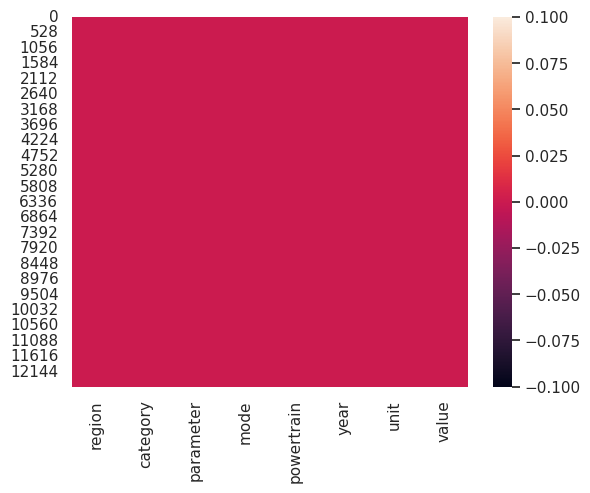

In [117]:
sns.heatmap(df.isnull())

In [118]:
import plotly.express as px

# Count values correctly
mode_counts = df["mode"].value_counts()

# Create pie chart
fig = px.pie(
    values=mode_counts.values,
    names=mode_counts.index,
)

# Layout settings
fig.update_layout(
    title="Distribution of EV Modes",
    plot_bgcolor="rgba(255,255,0,0.5)",  # fixed invalid RGBA
    paper_bgcolor="black",
    font=dict(color="white")
)
fig.show()

In [119]:
fig = px.bar(x=df["mode"]. value_counts().index,
             y=df["mode"].value_counts().values,
             color=df["mode"].value_counts().index)

fig.update_layout(
    title={
        'text': "Mode Counts",
        'font': {'color': 'White'}
    },


    xaxis_title={
        'text': "Count",
        'font': {'color': 'White'}
    },

    yaxis_title={
        'text': "Mode",
        'font': {'color': 'White'}
    },

    plot_bgcolor = 'rgba(0,0,0,0)',
    paper_bgcolor = 'black',
    font=dict(color='white')

)
fig.show()

In [120]:
max_row = vehicles.sort_values(['value', 'year']).iloc[0]
print(max_row)

region            Israel
category      Historical
parameter       EV sales
mode               Buses
powertrain           BEV
year                2013
unit            Vehicles
value              0.001
Name: 6151, dtype: object


In [121]:
min_row = vehicles.sort_values(['value', 'year']).iloc[0]
print(min_row)

region            Israel
category      Historical
parameter       EV sales
mode               Buses
powertrain           BEV
year                2013
unit            Vehicles
value              0.001
Name: 6151, dtype: object


In [122]:
max_row = vehicles.sort_values(['value', 'year']).iloc[-1]
print(max_row)

region                 World
category      Projection-APS
parameter           EV stock
mode                    Cars
powertrain               BEV
year                    2035
unit                Vehicles
value            440000000.0
Name: 12609, dtype: object


In [123]:
grouped_data = df.groupby(['region', 'value']).size().reset_index(name='total_value')
grouped_data = grouped_data.sort_values(by='total_value', ascending=False)
grouped_data = grouped_data.head(100)

fig = px.bar(grouped_data, x='region', y='total_value', color='region',
            title="Total Vehicle Sales by Region",
            labels={'region': "Region", 'total_value': 'Total_value'})


fig.update_layout(
    plot_bgcolor = 'rgba(0,0,0,0)',
    paper_bgcolor = 'black',
    font=dict(color='white')
)

fig.show()

In [124]:
vehicles_count= vehicles.groupby(by=['year', 'region']).count()['unit'].reset_index().sort_values(by='unit')
vehicles_count

,year,region,unit
0,2010,Austria,1
2,2010,Brazil,1
549,2022,Romania,1
550,2022,Seychelles,1
30,2011,Brazil,1
...,...,...,...
474,2021,Europe,72
578,2023,Europe,72
457,2020,World,72
465,2021,China,72


In [125]:

vehicles_countries_grouped = vehicles.groupby('region')['value'].sum()

#Converting the series into a dataframe
vehicles_countries_df = pd.DataFrame(vehicles_countries_grouped).reset_index()

#Renaming
vehicles_countries_df.columns = ['region', 'values']

#Droping the row world
vehicles_countries_df = vehicles_countries_df[vehicles_countries_df['region'] != 'World']

print(vehicles_countries_df)

                  region        values
0              Australia  5.788320e+05
1                Austria  8.719660e+05
2                Belgium  1.687010e+06
3                 Brazil  2.649470e+05
4               Bulgaria  4.623000e+03
5                 Canada  2.416440e+06
6                  Chile  1.445800e+04
7                  China  1.148052e+09
8               Colombia  1.602300e+04
9             Costa Rica  2.763100e+04
10               Croatia  7.557000e+03
11                Cyprus  2.260000e+03
12        Czech Republic  3.430000e+04
13               Denmark  1.102561e+06
14                  EU27  3.324256e+07
15               Estonia  4.585000e+03
16                Europe  5.937754e+08
17               Finland  7.427230e+05
18                France  6.787772e+06
19               Germany  1.020111e+07
20                Greece  1.053560e+05
21               Hungary  4.203500e+04
22               Iceland  1.897660e+05
23                 India  6.341878e+07
24               Ireland 

/tmp/ipykernel_162/3929841187.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




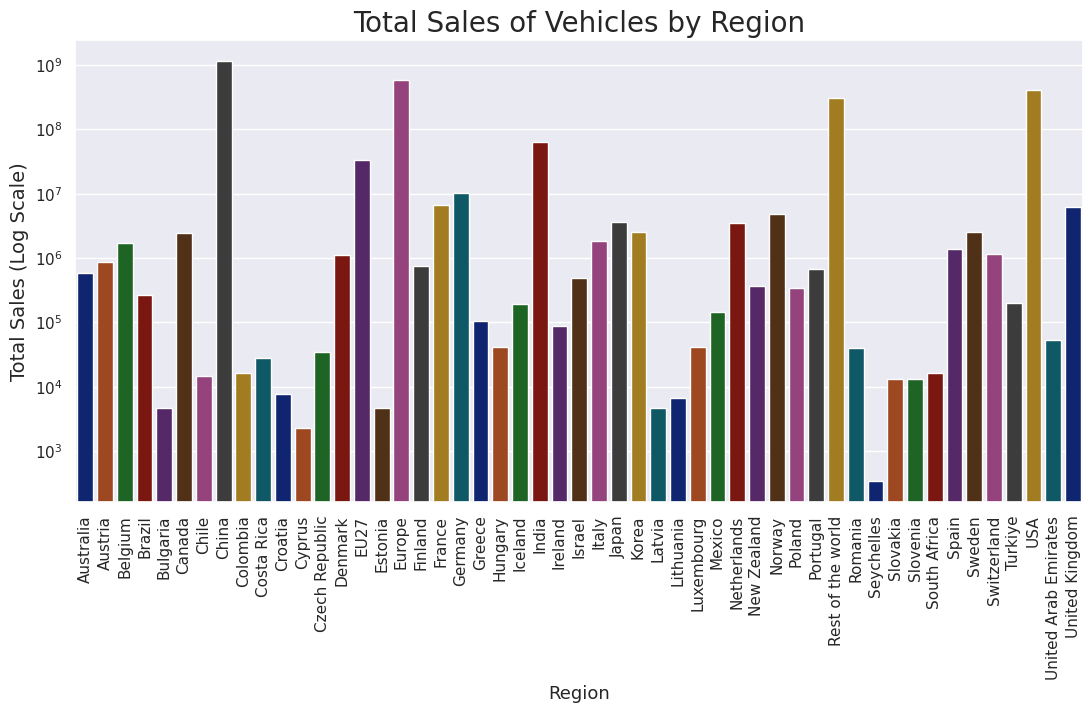

In [126]:
sns.set(style= "darkgrid")

#Here we creating the figure and axis
fig, axes = plt.subplots(ncols=1, nrows=1, figsize=(13, 6))
sns.barplot(data=vehicles_countries_df, x='region', y='values', palette="dark")

plt.xticks(rotation=90)#Rotation x-axis labels for better readability
plt.title('Total Sales of Vehicles by Region', fontsize=20, fontweight='light')
plt.xlabel('Region', fontsize=13)
plt.ylabel('Total Sales (Log Scale)', fontsize=14)


#Using a logarithmic sacle for the y-axis if values spana large range
plt.yscale('log')

plt.show()

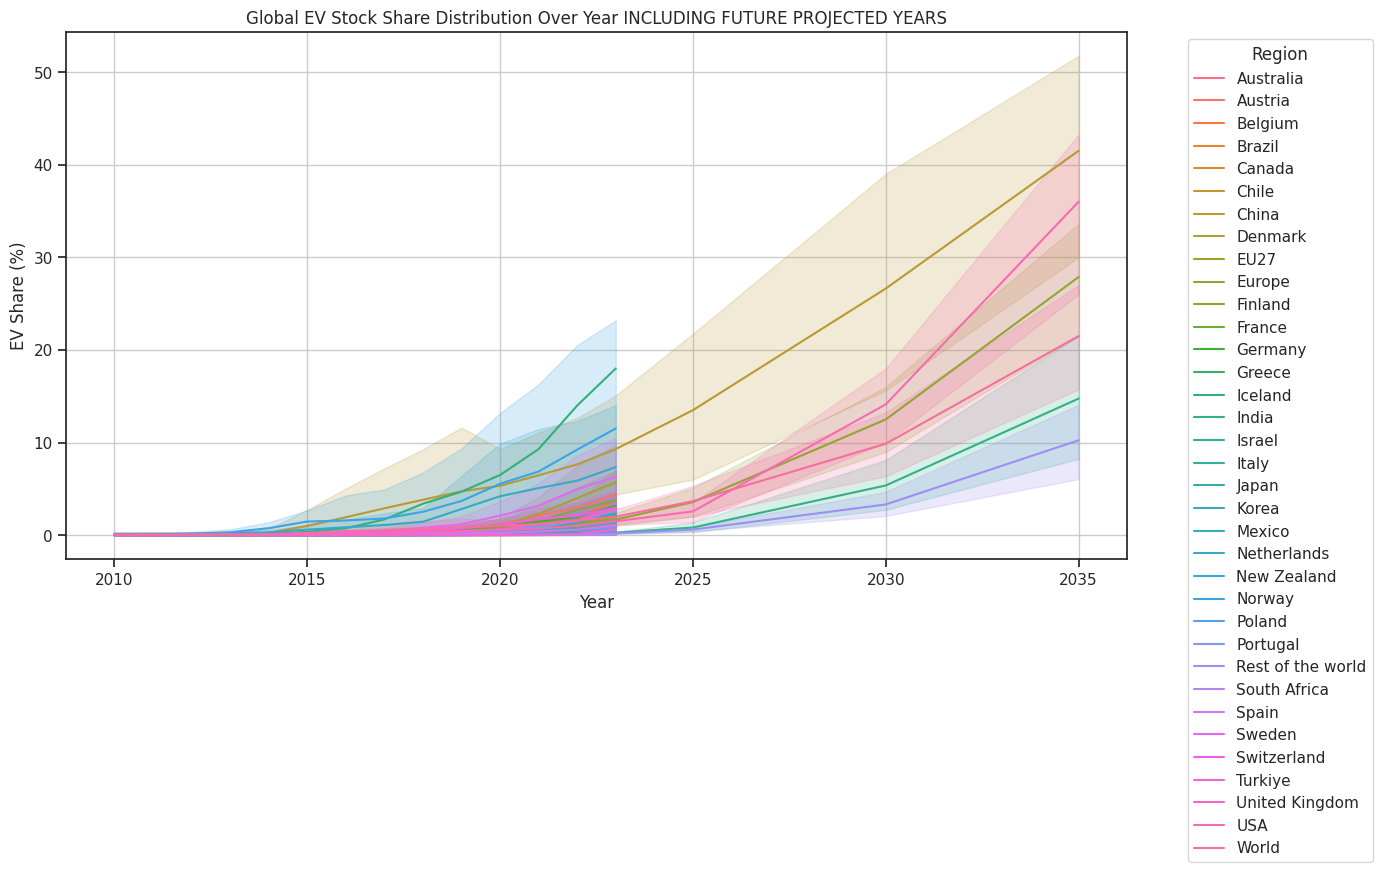

In [127]:
sns.set(style= "ticks")
ev_stock_share = df[df['parameter'] == 'EV stock share']

#Plotting the distribution of EV stock share over the years
plt.figure(figsize=(14, 8))
sns.lineplot(data=ev_stock_share, x='year', y='value', hue='region', markers=True)
plt.title('Global EV Stock Share Distribution Over Year INCLUDING FUTURE PROJECTED YEARS')
plt.xlabel('Year')
plt.ylabel('EV Share (%)')
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

In [128]:
express.scatter(data_frame=df, x='year', y='value',trendline='lowess', color='region', log_y=True)

In [129]:
plt.figure(figsize=(10,5))
sns.set_theme(style='darkgrid')

<Figure size 1000x500 with 0 Axes>

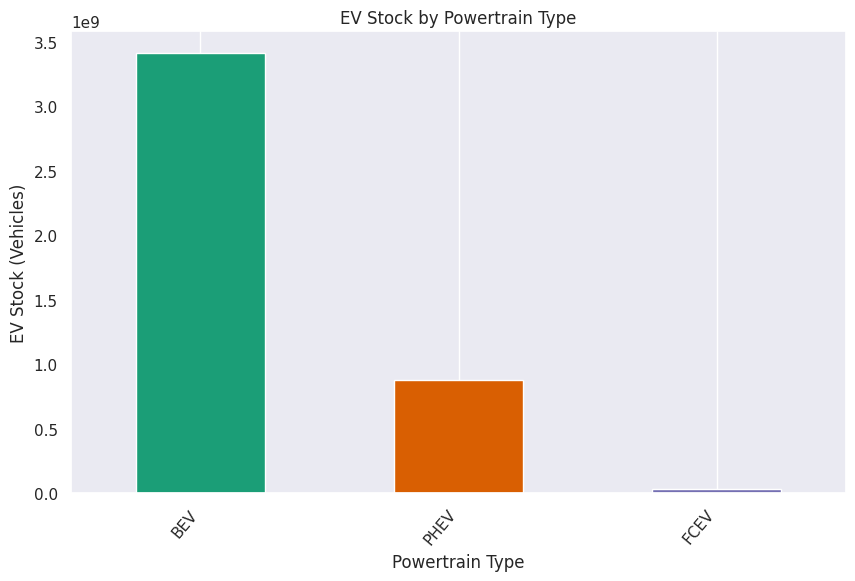

In [130]:
ev_stock = df[df['parameter'] == 'EV stock']

#Aggregate Ev stocks by powertrain type
ev_stock_by_powertrain = ev_stock.groupby('powertrain')['value'].sum().sort_values(ascending=False)

#Plotting
plt.figure(figsize=(10, 6))
ev_stock_by_powertrain.plot(kind='bar', color=plt.get_cmap('Dark2').colors)
plt.title('EV Stock by Powertrain Type')
plt.xlabel('Powertrain Type')
plt.ylabel('EV Stock (Vehicles)')
plt.xticks(rotation=50, ha='right')
plt.grid(axis='y')
plt.show()

In [131]:
fig = express.scatter(data_frame=ev_stock_share, x='year', y='value', trendline='lowess', color='region',
                     title='EV Stock Share Over Time by Region INCLUDING PROJECTED YEARS',
                     labels={'year': 'Year', 'value': 'EV Stock Share (%)'})
fig.update_layout(
    plot_bgcolor = 'rgba(0,0,0,0)',
    paper_bgcolor = 'black',
    font=dict(color='white')
)
fig.show()

# Continent


In [132]:
unique_regions = df['region'].unique()

country_to_continent = {
    'Australia': 'Oceania',
    'Austria': 'Europe',
    'Belgium': 'Europe',
    'Brazil': 'South America',
    'Bulgaria': 'Europe',
    'Canada': 'North America',
    'Chile': 'South America',
    'China': 'Asia',
    'Colombia': 'South America',
    'Costa Rica': 'North America',
    'Croatia': 'Europe',
    'Cyprus': 'Europe',
    'Czech Republic': 'Europe',
    'Denmark': 'Europe',
    'Estonia': 'Europe',
    'EU27': 'Europe',
    'Europe': 'Europe',
    'Finland': 'Europe',
    'France': 'Europe',
    'Germany': 'Europe',
    'Greece': 'Europe',
    'Hungary': 'Europe',
    'Iceland': 'Europe',
    'India': 'Asia',
    'Indonesia': 'Asia',
    'Ireland': 'Europe',
    'Israel': 'Asia',
    'Italy': 'Europe',
    'Japan': 'Asia',
    'Korea': 'Asia',
    'Latvia': 'Europe',
    'Lithuania': 'Europe',
    'Luxembourg': 'Europe',
    'Mexico': 'North America',
    'Netherlands': 'Europe',
    'New Zealand': 'Oceania',
    'Norway': 'Europe',
    'Poland': 'Europe',
    'Portugal': 'Europe',
    'Rest of the world': 'Other',
    'Romania': 'Europe',
    'Seychelles': 'Africa',
    'Slovakia': 'Europe',
    'Slovenia': 'Europe',
    'South Africa': 'Africa',
    'Spain': 'Europe',
    'Sweden': 'Europe',
    'Switzerland': 'Europe',
    'Thailand': 'Asia',
    'Turkiye': 'Asia',
    'United Arab Emirates': 'Asia',
    'United Kingdom': 'Europe',
    'USA': 'North America',
    'World': 'World'
}

print("Country to continent mapping dictionary created.")

Country to continent mapping dictionary created.


In [133]:
df['continent'] = df['region'].map(country_to_continent).fillna('Unknown')
df.head()

,region,category,parameter,mode,powertrain,year,unit,value,continent
0,Australia,Historical,EV stock share,Cars,EV,2011,percent,0.00039,Oceania
1,Australia,Historical,EV sales share,Cars,EV,2011,percent,0.00650,Oceania
2,Australia,Historical,EV sales,Cars,BEV,2011,Vehicles,49.00000,Oceania
3,Australia,Historical,EV stock,Cars,BEV,2011,Vehicles,49.00000,Oceania
4,Australia,Historical,EV stock,Cars,BEV,2012,Vehicles,220.00000,Oceania


In [134]:
vehicles_by_continent = df[df['unit'] == 'Vehicles']
vehicles_by_continent = vehicles_by_continent.groupby('continent')['value'].sum().reset_index()
vehicles_by_continent.columns = ['continent', 'total_value']
vehicles_by_continent = vehicles_by_continent[~vehicles_by_continent['continent'].isin(['World', 'Other'])]
vehicles_by_continent.head()

,continent,total_value
0,Africa,1.687100e+04
1,Asia,1.218324e+09
2,Europe,6.715312e+08
3,North America,4.138668e+08
4,Oceania,9.502940e+05


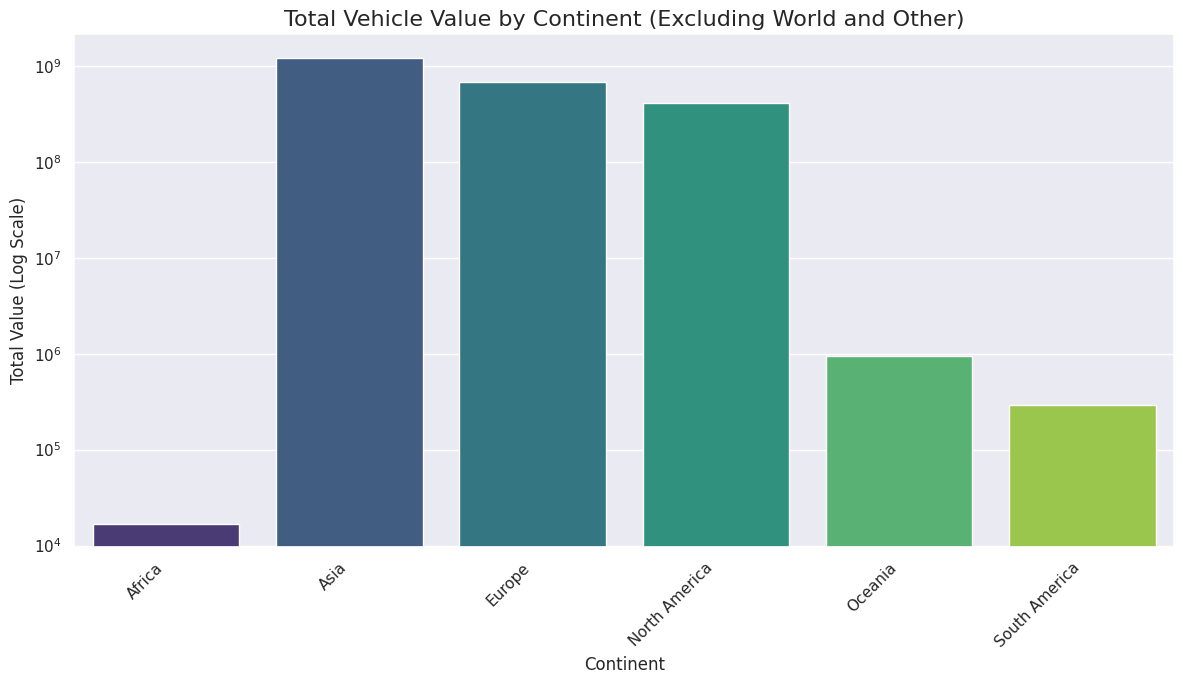

In [135]:
vehicles_by_continent = df[df['unit'] == 'Vehicles']
vehicles_by_continent = vehicles_by_continent.groupby('continent')['value'].sum().reset_index()
vehicles_by_continent.columns = ['continent', 'total_value']
vehicles_by_continent = vehicles_by_continent[~vehicles_by_continent['continent'].isin(['World', 'Other'])]

plt.figure(figsize=(12, 7))
sns.barplot(x='continent', y='total_value', data=vehicles_by_continent, palette='viridis', hue='continent', legend=False)
plt.title('Total Vehicle Value by Continent (Excluding World and Other)', fontsize=16)
plt.xlabel('Continent', fontsize=12)
plt.ylabel('Total Value (Log Scale)', fontsize=12)
plt.yscale('log')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# EV sales for each country by race chart (upto 2025 ie historical data)


In [136]:

import plotly.express as px

df = df[(df['parameter'] == 'EV sales') & (df['category'] == 'Historical')]
df = df[~df['region'].isin(['World', 'Europe', 'EU27', 'Rest of the world'])]
df = df.groupby(['region', 'year'])['value'].sum().reset_index()
df = df.sort_values(['year', 'value'], ascending=[True, False])

fig = px.bar(df, x='value', y='region', color='region',
             animation_frame='year', animation_group='region',
             orientation='h', title='Historical EV Sales by Country')
fig.update_layout(yaxis={'categoryorder': 'total ascending'})
fig.show()

In [137]:

from plotly.subplots import make_subplots
import plotly.graph_objects as go
df = pd.read_csv('IEA Global EV Data 2024.csv')
df = df[(df['parameter'] == 'EV sales') & (df['category'] == 'Historical')]

#  Plot 1: Countries vs yr
df_countries = df[~df['region'].isin(['World', 'Europe', 'EU27', 'Rest of the world'])]
df_countries = df_countries.groupby(['region', 'year'])['value'].sum().reset_index()

# Plot 2: Global Total vs yr
df_total = df[df['region'] == 'World'].groupby('year')['value'].sum().reset_index() #instead of finding sum we take the world data directly


fig = make_subplots(rows=1, cols=2, subplot_titles=("EV Sales by Country", "Total Global EV Sales"))

for region in df_countries['region'].unique():
    region_data = df_countries[df_countries['region'] == region]
    fig.add_trace(go.Scatter(x=region_data['year'], y=region_data['value'], name=region), row=1, col=1)


fig.add_trace(go.Scatter(x=df_total['year'], y=df_total['value'], name='Total Global', line=dict(color='black', width=3)), row=1, col=2)

fig.update_layout(height=500, title_text="EV Sales Analysis: Country-wise vs. Global Total", showlegend=True)
fig.show()

In [138]:
from sklearn.linear_model import LinearRegression
import plotly.graph_objects as go
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score


# Prediciton of EV Sales for future years by Models: XG Boost, Linear regressor, Random Forest(Fails to extrapolate)
## Training on historical data and Test data is the projected data given

In [139]:
df = pd.read_csv('IEA Global EV Data 2024.csv')

#Train Data: Historical Global EV Sales
df_hist = df[(df['region'] == 'World') & (df['parameter'] == 'EV sales') & (df['category'] == 'Historical')]
df_train = df_hist.groupby('year')['value'].sum().reset_index() #si

X_train = df_train[['year']]
y_train = df_train['value']

# Test Data: Projected Global EV Sales (From 2025 onwards)

df_proj = df[(df['region'] == 'World') & (df['parameter'] == 'EV sales') & (df['category'] == 'Projection-STEPS')]
df_test = df_proj.groupby('year')['value'].sum().reset_index()

# WE filter for test years 2025 and onwards
df_test = df_test[df_test['year'] >= 2023]
X_test = df_test[['year']] # future years for testing
y_test = df_test['value']


lr = LinearRegression().fit(X_train, y_train)
rf = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train, y_train)
gb = GradientBoostingRegressor(n_estimators=100, random_state=42).fit(X_train, y_train)


print(f"Linear Regression R2 Score: {r2_score(y_test, lr.predict(X_test)):.4f}")
print(f"Random Forest R2 Score: {r2_score(y_test, rf.predict(X_test)):.4f}")
print(f"Gradient Boosting R2 Score: {r2_score(y_test, gb.predict(X_test)):.4f}")


preds_lr = lr.predict(X_test)
preds_rf = rf.predict(X_test)
preds_gb = gb.predict(X_test)


fig = go.Figure()

# Actual Historical Data
fig.add_trace(go.Scatter(x=df_train['year'], y=df_train['value'],
                         mode='markers+lines', name='Actual Historical Sales',
                         line=dict(color='black', width=3), marker=dict(size=8)))

#actual forecasted targets (y_test)
fig.add_trace(go.Scatter(x=X_test['year'], y=y_test,
                         mode='markers+lines', name='Official Projection (Target)',
                         line=dict(color='orange', width=3), marker=dict(size=8)))

# Linear Regression Predictions
fig.add_trace(go.Scatter(x=X_test['year'], y=preds_lr,
                         mode='lines', name='Linear Regression (Pred)',
                         line=dict(dash='dash', color='blue')))

# Random Forest Predictions
fig.add_trace(go.Scatter(x=X_test['year'], y=preds_rf,
                         mode='lines', name='Random Forest (Pred)',
                         line=dict(dash='dot', color='green')))

# Gradient Boosting Predictions
fig.add_trace(go.Scatter(x=X_test['year'], y=preds_gb,
                         mode='lines', name='Gradient Boosting (Pred)',
                         line=dict(dash='dashdot', color='red')))


fig.update_layout(
    title='Historical vs Model Predictions vs Official Target (2010 - 2035)',
    xaxis_title='Year',
    yaxis_title='Total EV Sales',
    hovermode='x unified',
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
)

fig.show()

Linear Regression R2 Score: -1.0182
Random Forest R2 Score: -1.4821
Gradient Boosting R2 Score: -1.2771


## Prediciton of EV Sales by Poly. Regression(degree 2)
## (R2=0.9618)

In [140]:
df = pd.read_csv('IEA Global EV Data 2024.csv')

# Train Data: Historical
df_hist = df[(df['region'] == 'World') & (df['parameter'] == 'EV sales') & (df['category'] == 'Historical')]
df_train = df_hist.groupby('year')['value'].sum().reset_index()

X_train = df_train[['year']]
y_train = df_train['value']

#Test Data: Projected (From 2025 onwards)
df_proj = df[(df['region'] == 'World') & (df['parameter'] == 'EV sales') & (df['category'] == 'Projection-STEPS')]
df_test = df_proj.groupby('year')['value'].sum().reset_index()
df_test = df_test[df_test['year'] >= 2023]

X_test = df_test[['year']]
y_test = df_test['value']

poly_feat = PolynomialFeatures(degree=2)
X_train_poly = poly_feat.fit_transform(X_train)
X_test_poly = poly_feat.transform(X_test)

# smooitgenn more
poly_model = LinearRegression().fit(X_train_poly, y_train)


preds_poly = poly_model.predict(X_test_poly)
print(f"Polynomial Regression (Deg 2) R2 Score: {r2_score(y_test, preds_poly):.4f}")



Polynomial Regression (Deg 2) R2 Score: 0.9646


# The ARIMA time series model
## Model treats each yr as a continuation of last one. so starts from the last historical

In [141]:
df = pd.read_csv('IEA Global EV Data 2024.csv')

# Training Data:Historical
df_hist = df[(df['region'] == 'World') & (df['parameter'] == 'EV sales') & (df['category'] == 'Historical')]
df_train = df_hist.groupby('year')['value'].sum().reset_index().sort_values('year')
y_train = df_train['value'].values

# Prepare Test Data (Projected 2023 onwards)
df_proj = df[(df['region'] == 'World') & (df['parameter'] == 'EV sales') & (df['category'] == 'Projection-STEPS')]
df_test = df_proj.groupby('year')['value'].sum().reset_index().sort_values('year')
df_test = df_test[df_test['year'] >= 2023]


# d=2 (Differencing for growth)
model = ARIMA(y_train, order=(1, 2, 1))
model_fit = model.fit()

#  Forecast (2024 to 2035)
forecast_steps = 12 # Forecasting 12 years from 2023
forecast = model_fit.forecast(steps=forecast_steps)


forecast_years = np.arange(2024, 2036)
forecast_df = pd.DataFrame({'year': forecast_years, 'forecast': forecast})

comparison = pd.merge(df_test, forecast_df, on='year')
r2_arima = r2_score(comparison['value'], comparison['forecast'])

print(f"ARIMA R2 Score: {r2_arima:.4f}")


ARIMA R2 Score: 0.9986


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning:

Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.



The "2020 Surge" Problem

Between 2010 and 2019, the EV market was growing, but it was doing so at a relatively "steady" pace. However, between 2020 and 2023, the global market experienced a massive, unprecedented surge (due to policy shifts, battery price drops, and new model launches).

    Training on 2010–2019: The model learns a "slow and steady" curve.

    Predicting 2020–2023: The model significantly under-predicts reality because it has no way of knowing that a massive acceleration was about to happen.

In [142]:

fig = go.Figure()

#actual historicsl
fig.add_trace(go.Scatter(
    x=df_train['year'],
    y=df_train['value'],
    mode='markers+lines',
    name='Actual History',
    line=dict(color='black', width=3)
))

# Official IEA Projection
fig.add_trace(go.Scatter(
    x=df_test['year'],
    y=df_test['value'],
    mode='markers+lines',
    name='Official IEA Target (STEPS)',
    line=dict(color='orange', width=3)
))

# ARIMA Forecast
fig.add_trace(go.Scatter(
    x=forecast_df['year'],
    y=forecast_df['forecast'],
    mode='lines',
    name='ARIMA Forecast',
    line=dict(color='green', dash='dash')
))

# Polynomial Prediction
fig.add_trace(go.Scatter(
    x=full_years.flatten(),
    y=preds_poly_full,
    mode='lines',
    name='Polynomial Pred (Deg 2). ',
    line=dict(color='purple', dash='dashdot')
))


fig.update_layout(
    title='Comparison: ARIMA vs Polynomial Regression vs IEA Projections',
    xaxis_title='Year',
    yaxis_title='Total EV Sales',
    hovermode='x unified',
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01
    )
)

fig.show()